# BTC vol: autocorrelation, market opens, and its link to ES

Framing: the target trade is the **Polymarket 5-minute BTC up/down** market (settled on Chainlink BTC/USD; Binance
spot is the proxy here, 1s klines 2023-05 → now). What matters for that market is the distribution of the
*next* 5-minute return, so every question below is asked at short horizons and in clock-aligned 5-minute windows:

1. **BTC 5-min return anatomy** — vol by time of day / weekday vs weekend, how often a window is essentially flat,
   whether 5-min returns themselves are autocorrelated (momentum / reversal).
2. **BTC vol autocorrelation** at 1-min and 5-min resolution, fits, and a next-window RV forecast (HAR at 5-min).
3. **BTC vol around market opens** — weekends (no ES, no US session) are the natural control for "is it the
   time of day or the US market?".
4. **BTC vol response to ES moves** — conditional on ES's last minute / ES vol shocks.
5. **Vol co-movement made stationary** — levels share a regime; the question is whether an *increase* in ES vol
   is followed by an increase in BTC vol, so the work is done on innovations (Δ log RV, AR residuals).
6. **ES → BTC beta** by horizon (10 s → 1 d), lead–lag, by session, rolling, conditional on move size, and
   *within* a 5-min window (ES's first k minutes vs BTC's remaining minutes).

**Memory plan.** Three cached inputs, each built by one streaming pass and then read from `data/derived/`:
`es_rv_1min` (from the ES notebook — built here if missing), `btc_rv_1min` (1s klines, one month at a time),
and `grid_10s` (BTC close + ES swmid every 10 s, ~10M rows / ~250 MB — the one big frame; shrink `START` if the
kernel is busy). Everything else is derived from these.

In [1]:
import sys, os
sys.path.insert(0, "/home/joshua/btc"); os.chdir("/home/joshua/btc"); sys.path.insert(0, "/home/joshua/btc/analysis")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
import statsmodels.api as sm
from scipy.optimize import curve_fit
from volutils import (ET, ann, MIN_PER_YR, MIN_PER_YR_24_7, tod_dow, hhmm, cached, DERIVED,
                      build_es_rv_1min, build_btc_rv_1min, build_grid_10s,
                      acf, fit_acf, plot_acf_fits, shock_response, deseasonalise)

START = "2023-05-16"                         # first BTC 1s kline month on disk; ES goes back to 2021-11
END = None
EVENTS = {"Globex open": 18 * 60, "Europe open": 3 * 60, "US data 08:30": 8 * 60 + 30, "Cash open": 9 * 60 + 30,
          "10:00 data": 10 * 60, "FOMC 14:00": 14 * 60, "Cash close": 16 * 60, "Break 17:00": 17 * 60}
sess = lambda tod: (tod - 18 * 60) % 1440    # minutes since the 18:00 ET Globex open (x-axis convention)

In [2]:
es_rv = cached(DERIVED / "es_rv_1min.parquet", build_es_rv_1min)
btc_rv = cached(DERIVED / "btc_rv_1min.parquet", build_btc_rv_1min)
grid = cached(DERIVED / f"grid_10s_{START}.parquet", build_grid_10s, start=START, end=END)

es_rv = es_rv[(es_rv.index >= pd.Timestamp(START, tz="UTC")) & (es_rv.n > 0)].copy()
btc_rv = btc_rv[(btc_rv.index >= pd.Timestamp(START, tz="UTC")) & (btc_rv.n > 0)].copy()
for d in (es_rv, btc_rv):
    d["tod"], d["dow"] = tod_dow(d.index)
es_rv = es_rv[~es_rv.tod.between(17 * 60, 18 * 60 - 1)]          # maintenance break: sparse pre-open indications
btc_rv["weekend"] = btc_rv.dow >= 5
btc_rv["es_open"] = btc_rv.index.isin(es_rv.index)                # ES quoted in this minute
print(f"ES  {len(es_rv):,} minutes  {es_rv.index[0]:%Y-%m-%d} -> {es_rv.index[-1]:%Y-%m-%d}")
print(f"BTC {len(btc_rv):,} minutes  {btc_rv.index[0]:%Y-%m-%d} -> {btc_rv.index[-1]:%Y-%m-%d}, ES open in {btc_rv.es_open.mean():.1%} of them")
print(f"grid {len(grid):,} x 10s rows, {grid.memory_usage().sum() / 1e6:.0f} MB, ES present {grid.es.notna().mean():.1%}")
print(f"annualised vol (all minutes): BTC {ann(btc_rv.rv.mean(), MIN_PER_YR_24_7):.3f}, "
      f"BTC while ES open {ann(btc_rv.rv[btc_rv.es_open].mean(), MIN_PER_YR_24_7):.3f}, closed {ann(btc_rv.rv[~btc_rv.es_open].mean(), MIN_PER_YR_24_7):.3f}")

ES  1,173,390 minutes  2023-05-16 -> 2026-09-11
BTC 1,750,394 minutes  2023-05-16 -> 2026-09-12, ES open in 67.0% of them
grid 10,502,362 x 10s rows, 347 MB, ES present 56.8%
annualised vol (all minutes): BTC 0.388, BTC while ES open 0.430, closed 0.286


## 1. The 5-minute BTC return

Clock-aligned windows (`:00, :05, …`, as the market uses). `r5` is the log return from the first to the last
10-s grid point of the window. Vol is annualised on a 24/7 clock (`sqrt(var × 365.25 × 288)`), so 1 ≈ 100%/yr.

350,078 windows; sd 0.00145 (ann. 0.471); skew -1.03; excess kurt 104.5
P(up) = 0.4982  P(exactly 0) = 0.3625%
P(|r5| < 1 bp) = 10.69%   P(|r5| < 2 bp) = 20.43%   P(|r5| < 5 bp) = 44.50%   P(|r5| < 10 bp) = 69.73%   


ACF of r5     lags 1..12: [-0.016  -0.0144 -0.0004 -0.0054  0.003  -0.0014 -0.0027 -0.0047  0.
  0.0014 -0.0089  0.0022]
ACF of sign   lags 1..12: [-0.0129 -0.0192 -0.0117 -0.0108 -0.0089 -0.004  -0.0054 -0.0083 -0.0032
 -0.0033 -0.0036  0.0026]
P(up | prev up) = 0.4918   P(up | prev down) = 0.5046   (2 s.e. ≈ 0.0034)


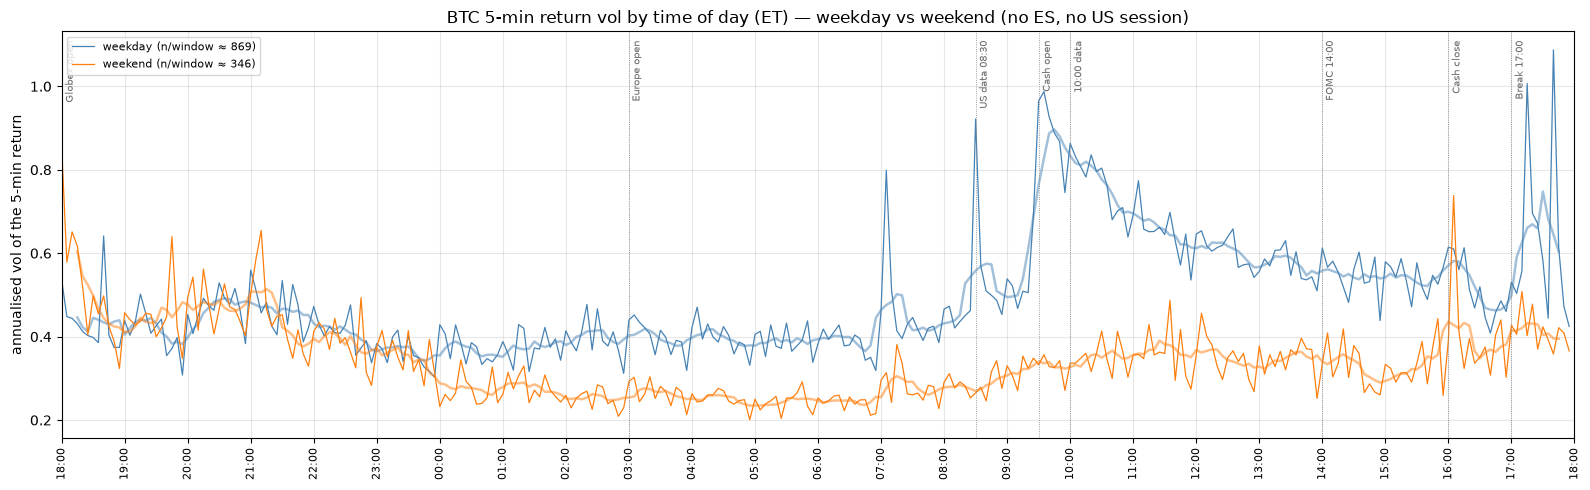

In [3]:
p5 = grid.btc[(grid.index.asi8 % (300 * 10**9)) == 0]            # BTC close at each window start
r5 = np.log(p5).diff().shift(-1).dropna()                          # return over the window starting at the index
r5 = r5[(r5.index.to_series().diff().shift(-1) == pd.Timedelta("5min")) | (r5.index == r5.index[-1])]
w = pd.DataFrame({"r5": r5}); w["tod"], w["dow"] = tod_dow(w.index); w["weekend"] = w.dow >= 5
w["es_open"] = w.index.isin(es_rv.index.floor("5min"))
ANN5 = 365.25 * 288

print(f"{len(w):,} windows; sd {w.r5.std():.5f} (ann. {w.r5.std() * np.sqrt(ANN5):.3f}); skew {w.r5.skew():+.2f}; excess kurt {w.r5.kurt():.1f}")
print("P(up) =", f"{(w.r5 > 0).mean():.4f}", " P(exactly 0) =", f"{(w.r5 == 0).mean():.4%}")
for bp in (1, 2, 5, 10):
    print(f"P(|r5| < {bp} bp) = {(w.r5.abs() < bp * 1e-4).mean():.2%}", end="   ")
print()

# vol by time of day, weekday vs weekend, in session order
prof5 = w.groupby(["weekend", "tod"]).r5.agg(sd="std", n="size").reset_index()
fig, ax = plt.subplots(figsize=(16, 5))
for wk, colour, lab in ((False, "steelblue", "weekday"), (True, "tab:orange", "weekend")):
    p = prof5[prof5.weekend == wk].assign(s=lambda d: sess(d.tod)).sort_values("s")
    ax.plot(p.s, p.sd * np.sqrt(ANN5), lw=0.9, color=colour, label=f"{lab} (n/window ≈ {p.n.mean():.0f})")
    ax.plot(p.s, p.sd.rolling(6, center=True).mean() * np.sqrt(ANN5), lw=1.8, color=colour, alpha=0.5)
for name, m in EVENTS.items():
    ax.axvline(sess(m), color="grey", lw=0.6, ls=":"); ax.text(sess(m) + 3, ax.get_ylim()[1] * 0.98, name, rotation=90, va="top", fontsize=7, color="dimgrey")
ticks = np.arange(0, 1441, 60); ax.set_xticks(ticks); ax.set_xticklabels([hhmm(18 * 60 + t) for t in ticks], rotation=90, fontsize=8)
ax.set_ylabel("annualised vol of the 5-min return"); ax.set_title("BTC 5-min return vol by time of day (ET) — weekday vs weekend (no ES, no US session)")
ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=0.3); ax.set_xlim(0, 1440); fig.tight_layout()

# is there anything in the sign? autocorrelation of r5 and of sign(r5), and P(up | last window up)
lags = np.arange(1, 13)
ac_r = [w.r5.autocorr(k) for k in lags]; ac_s = [np.sign(w.r5).autocorr(k) for k in lags]
print("ACF of r5     lags 1..12:", np.round(ac_r, 4))
print("ACF of sign   lags 1..12:", np.round(ac_s, 4))
up = w.r5 > 0
print(f"P(up | prev up) = {up[up.shift(1) == True].mean():.4f}   P(up | prev down) = {up[up.shift(1) == False].mean():.4f}   (2 s.e. ≈ {2 / np.sqrt(len(w)):.4f})")

## 2. BTC vol autocorrelation at short horizons

Per-minute and per-5-min realised variance from the 1s closes, deseasonalised by minute-of-day **and**
weekend flag (`x = rv / mean rv at that minute for weekday|weekend`, baseline 1), then `log x`. BTC has no
gaps so lags are plain clock lags. Fitted shapes as in the ES notebook: exponential (single half-life),
power law (long memory), two exponentials (fast + slow).

1-min ACF at 1, 5, 30, 60, 1440: [0.509 0.435 0.384 0.359 0.226]    5-min ACF at 1, 6, 12, 288: [0.702 0.587 0.542 0.356]


,R2 (log-spaced lags),params,half-life
model,,,
exponential,0.861302,"0.3576, 2302",1595.7 min
power law,0.900796,"0.6121, 0.1502",alpha=0.150: rho halves every x101.1 in lag
two exponentials,0.986436,"0.1398, 78.34, 0.2936, 3603","fast 54.3 min (weight 32%), slow 2497 min"


,R2 (log-spaced lags),params,half-life
model,,,
exponential,0.810486,"0.4867, 785.1",544.2 x5min
power law,0.956713,"0.8018, 0.1621",alpha=0.162: rho halves every x71.9 in lag
two exponentials,0.984262,"0.2274, 25.25, 0.4166, 1208","fast 17.5 x5min (weight 35%), slow 837 x5min"


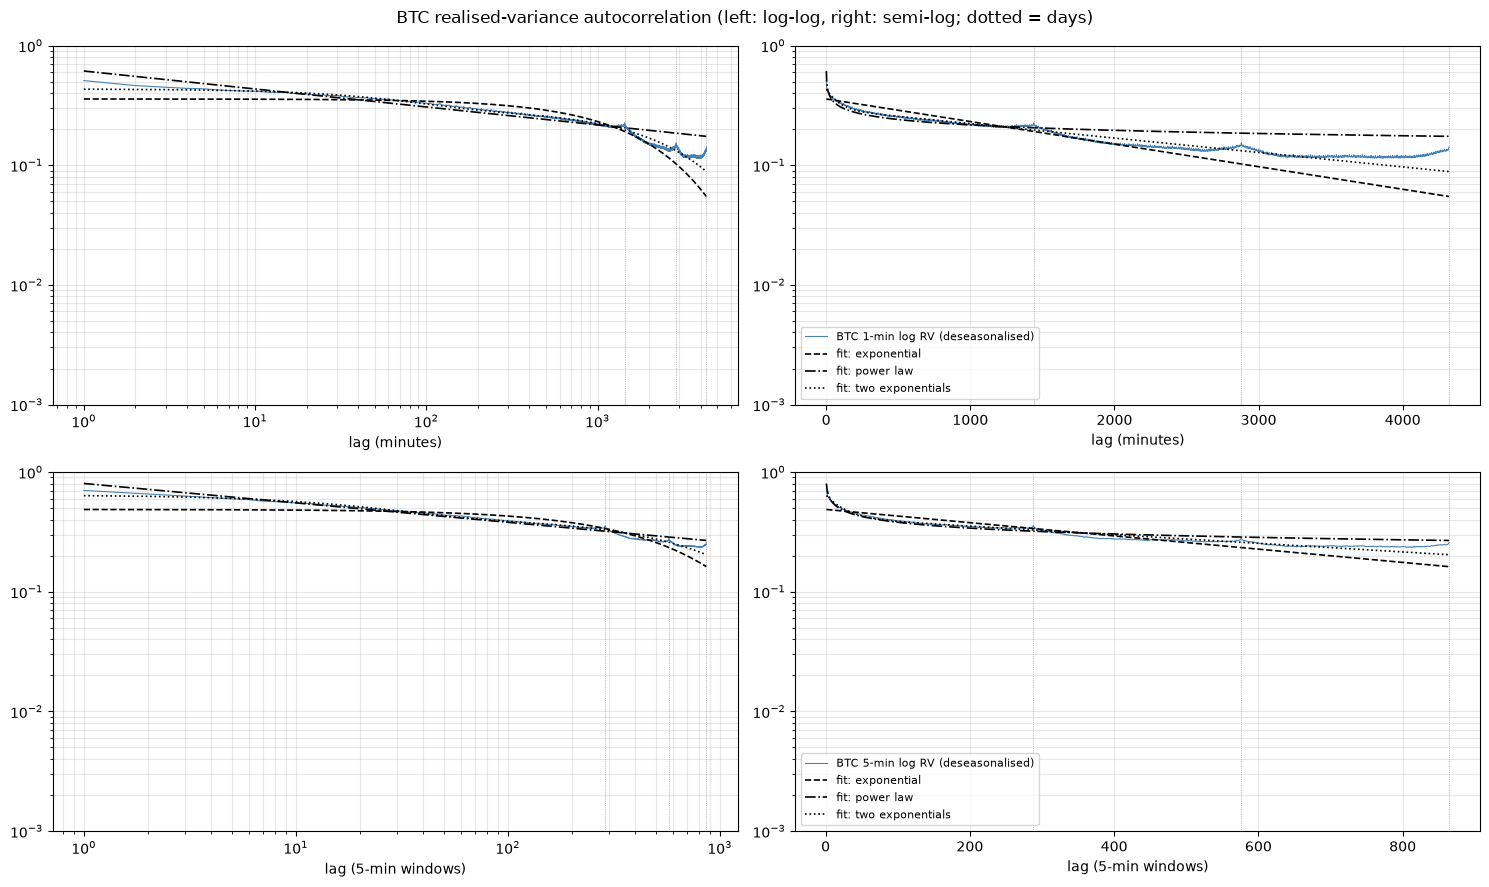

In [4]:
MIN_N = 20
btc_rv["x"], btc_rv["s"] = deseasonalise(btc_rv.rv, btc_rv.tod, btc_rv.weekend)
good_b = (btc_rv.n >= MIN_N) & (btc_rv.rv > 0)
xb = btc_rv.loc[good_b, ["x", "tod", "dow", "weekend", "es_open"]].copy(); xb["lx"] = np.log(xb.x)

# 5-min windows of RV
rv5 = btc_rv.groupby(btc_rv.index.floor("5min")).agg(rv=("rv", "sum"), n=("n", "sum"))
rv5 = rv5[rv5.n >= 200]
rv5["tod"], rv5["dow"] = tod_dow(rv5.index); rv5["weekend"] = rv5.dow >= 5
rv5["x"], rv5["s"] = deseasonalise(rv5.rv, rv5.tod, rv5.weekend); rv5["lx"] = np.log(rv5.x)
rv5["es_open"] = rv5.index.isin(es_rv.index.floor("5min"))

K1, K5 = 3 * 1440, 3 * 288
rho1 = acf(xb.lx, K1); tab1, cur1 = fit_acf(rho1, K1, unit="min")
rho5 = acf(rv5.lx, K5); tab5, cur5 = fit_acf(rho5, K5, unit="x5min")
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
plot_acf_fits(axes[0, 0], axes[0, 1], rho1, cur1, K1, "BTC 1-min log RV (deseasonalised)", day_len=1440)
plot_acf_fits(axes[1, 0], axes[1, 1], rho5, cur5, K5, "BTC 5-min log RV (deseasonalised)", day_len=288)
axes[0, 1].legend(fontsize=8); axes[1, 1].legend(fontsize=8); axes[1, 0].set_xlabel("lag (5-min windows)"); axes[1, 1].set_xlabel("lag (5-min windows)")
axes[0, 0].set_xlabel("lag (minutes)"); axes[0, 1].set_xlabel("lag (minutes)")
fig.suptitle("BTC realised-variance autocorrelation (left: log-log, right: semi-log; dotted = days)"); fig.tight_layout()
print("1-min ACF at 1, 5, 30, 60, 1440:", np.round(rho1[[1, 5, 30, 60, 1440]], 3), "   5-min ACF at 1, 6, 12, 288:", np.round(rho5[[1, 6, 12, 288]], 3))
display(tab1); tab5

In [5]:
# How predictable is the NEXT window's variance? HAR on 5-min deseasonalised log RV, plus a ratio table.
y = rv5.lx.to_numpy(); n = len(y)
roll = lambda k: pd.Series(y).rolling(k).mean().to_numpy()
X = pd.DataFrame({"last 5min": y, "last 30min": roll(6), "last 2h": roll(24), "last 24h": roll(288), "last week": roll(288 * 7)})
split = int(0.7 * n); rows = []
for hz_name, hz in (("next 5min", 1), ("next 15min", 3), ("next 1h", 12), ("next 24h", 288)):
    target = np.roll(pd.Series(y[::-1]).rolling(hz).mean().to_numpy()[::-1], -1); target[-hz:] = np.nan
    ok = np.isfinite(target) & X.notna().all(axis=1).to_numpy(); tr, te = ok.copy(), ok.copy(); tr[split:] = False; te[:split] = False
    for model, cols in (("HAR", list(X.columns)), ("AR(1)", ["last 5min"]), ("last 30min only", ["last 30min"])):
        Xc = sm.add_constant(X[cols]); fit = sm.OLS(target[tr], Xc[tr]).fit(); pred = fit.predict(Xc[te])
        row = {"horizon": hz_name, "model": model, "R2 in": fit.rsquared, "R2 out": 1 - ((target[te] - pred) ** 2).sum() / ((target[te] - target[tr].mean()) ** 2).sum()}
        row.update({f"b {c}": fit.params[c] for c in cols}); rows.append(row)
har5 = pd.DataFrame(rows).set_index(["horizon", "model"])
display(har5.style.format("{:.3f}", na_rep="").background_gradient(subset=["R2 out"], cmap="Blues"))

# Plain-language version: given this window's vol decile, what is the next window's vol relative to seasonal normal?
dec = pd.qcut(rv5.x, 10, labels=False)
nxt = pd.DataFrame({"decile": dec, "x next": rv5.x.shift(-1), "x +2": rv5.x.shift(-2), "x +6 (30min)": rv5.x.shift(-6), "x +12 (1h)": rv5.x.shift(-12), "x +288 (1d)": rv5.x.shift(-288)}).dropna()
rt = nxt.groupby("decile").agg(["mean", "median"]).apply(np.sqrt)   # sqrt: variance ratio -> vol ratio
rt.columns = [f"{a} ({b})" for a, b in rt.columns]
rt.index = [f"D{i + 1}" for i in rt.index]
print("vol multiple of the seasonal baseline in later windows, by decile of the current window's vol:")
rt.style.format("{:.2f}").background_gradient(cmap="RdBu_r", vmin=0.5, vmax=1.5)

vol multiple of the seasonal baseline in later windows, by decile of the current window's vol:


,x next (mean),x next (median),x +2 (mean),x +2 (median),x +6 (30min) (mean),x +6 (30min) (median),x +12 (1h) (mean),x +12 (1h) (median),x +288 (1d) (mean),x +288 (1d) (median)
D1,0.37,0.26,0.41,0.28,0.46,0.29,0.51,0.31,0.72,0.39
D2,0.47,0.36,0.51,0.38,0.57,0.39,0.61,0.41,0.77,0.46
D3,0.54,0.44,0.58,0.44,0.64,0.46,0.68,0.47,0.80,0.51
D4,0.61,0.50,0.65,0.51,0.70,0.52,0.75,0.53,0.84,0.55
D5,0.68,0.57,0.72,0.58,0.77,0.58,0.81,0.59,0.90,0.60
D6,0.76,0.65,0.79,0.64,0.85,0.64,0.90,0.64,0.95,0.64
D7,0.86,0.74,0.89,0.73,0.94,0.72,0.98,0.71,1.03,0.69
D8,1.00,0.86,1.03,0.84,1.06,0.82,1.06,0.80,1.09,0.75
D9,1.21,1.07,1.23,1.03,1.23,0.98,1.25,0.94,1.23,0.84
D10,2.17,1.62,2.08,1.53,1.93,1.37,1.80,1.27,1.44,1.01


### Shock decay in BTC vol

Same event study as for ES: top-1% / top-0.1% minutes of deseasonalised BTC variance, then the mean excess over
the following minutes, split by whether ES was open at the time.

,n,x at 0,x at -1,x at +1,x at +5,x at +30,x at +120,exp half-life (min),power alpha,first k with excess < 10%
shock,,,,,,,,,,
"top 1.0%, ES open",1.18e+04,24.7,18.9,18.4,14.1,9.39,5.15,285,0.336,-
"top 1.0%, ES closed",5.74e+03,27.1,19.8,19.1,14.7,8.76,4.95,227,0.38,-
"top 0.1%, ES open",1.11e+03,85.6,58.8,60,38.7,19.4,6.77,157,0.461,-
"top 0.1%, ES closed",644,93.2,64.8,66.8,48.8,20.2,6.91,30.6,0.549,-


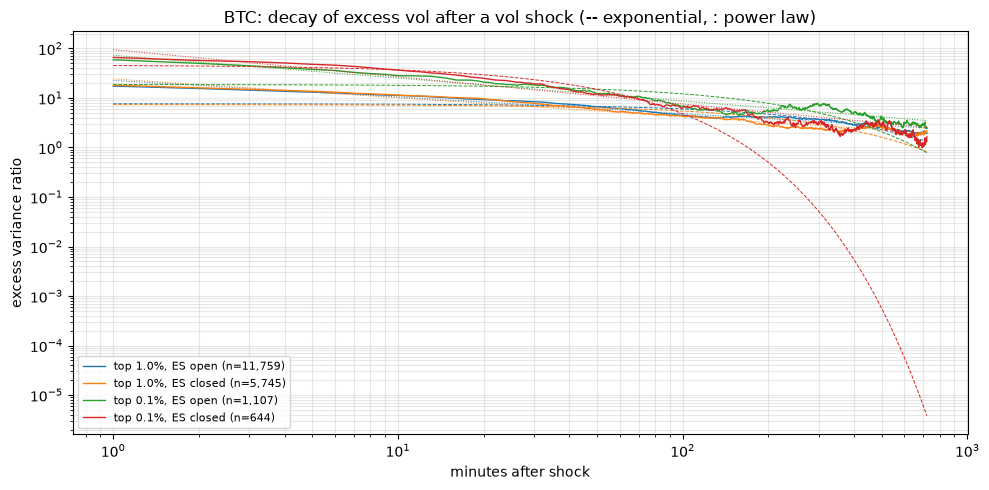

In [6]:
xv = xb.x.to_numpy(); eso = xb.es_open.to_numpy(); rows = []
fig, ax = plt.subplots(figsize=(10, 5))
for q in (0.99, 0.999):
    thr = np.quantile(xv, q)
    for lab, m in (("ES open", (xv > thr) & eso), ("ES closed", (xv > thr) & ~eso)):
        ks, resp, nn = shock_response(xv, np.flatnonzero(m), K=720, PRE=30)
        ex = resp - 1; kk = ks[ks >= 1]; ee = ex[ks >= 1]
        line, = ax.plot(kk[ee > 0], ee[ee > 0], lw=1, label=f"top {1 - q:.1%}, {lab} (n={nn:,})")
        row = {"shock": f"top {1 - q:.1%}, {lab}", "n": nn, "x at 0": resp[ks == 0][0], "x at -1": resp[ks == -1][0], "x at +1": resp[ks == 1][0],
               "x at +5": resp[ks == 5][0], "x at +30": resp[ks == 30][0], "x at +120": resp[ks == 120][0]}
        try:
            pe, _ = curve_fit(lambda k, a, t: a * np.exp(-k / t), kk[ee > 0], ee[ee > 0], p0=[ee[0], 30], bounds=([0, 0.1], [np.inf, 1e5]), maxfev=20000)
            pp, _ = curve_fit(lambda k, c, al: c * k ** (-al), kk[ee > 0], ee[ee > 0], p0=[ee[0], 0.5], bounds=([0, 0], [np.inf, 5]), maxfev=20000)
            ax.plot(kk, pe[0] * np.exp(-kk / pe[1]), ls="--", lw=0.7, color=line.get_color()); ax.plot(kk, pp[0] * kk ** (-pp[1]), ls=":", lw=0.7, color=line.get_color())
            row.update({"exp half-life (min)": pe[1] * np.log(2), "power alpha": pp[1],
                        "first k with excess < 10%": next((int(k) for k, e in zip(kk, ee) if e < 0.1), np.nan)})
        except RuntimeError:
            pass
        rows.append(row)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("minutes after shock"); ax.set_ylabel("excess variance ratio"); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
ax.set_title("BTC: decay of excess vol after a vol shock (-- exponential, : power law)"); fig.tight_layout()
pd.DataFrame(rows).set_index("shock").style.format("{:.3g}", na_rep="-")

## 3. BTC vol around market opens

The profile above already shows BTC in session order. Here: the weekday / weekend ratio by minute of day
(how much of BTC's intraday shape is *US-market-driven* rather than clock-driven — the weekend line has neither
ES nor US equities), and the decay after each open for BTC next to ES's.

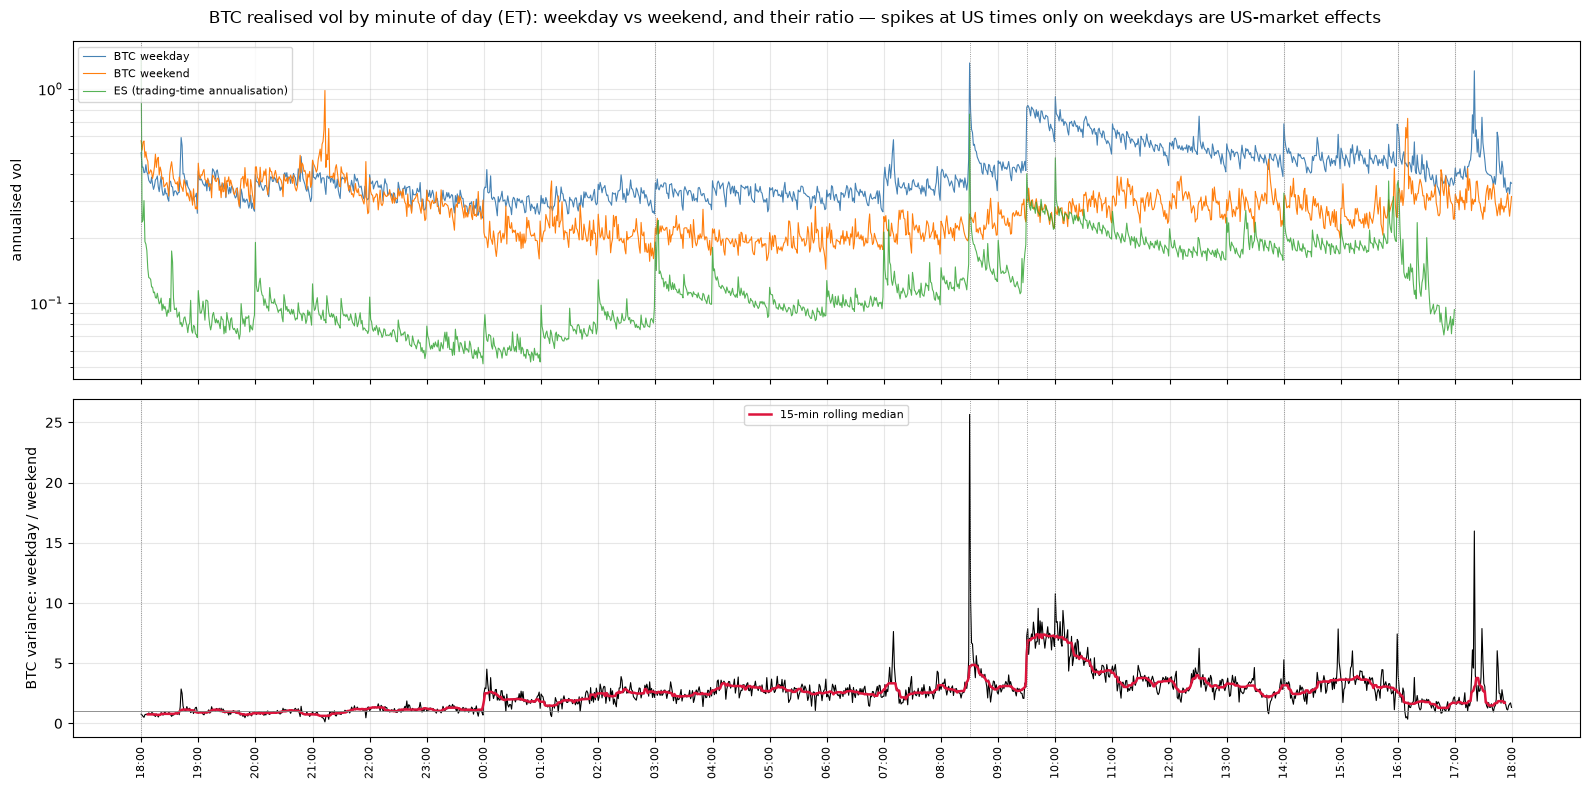

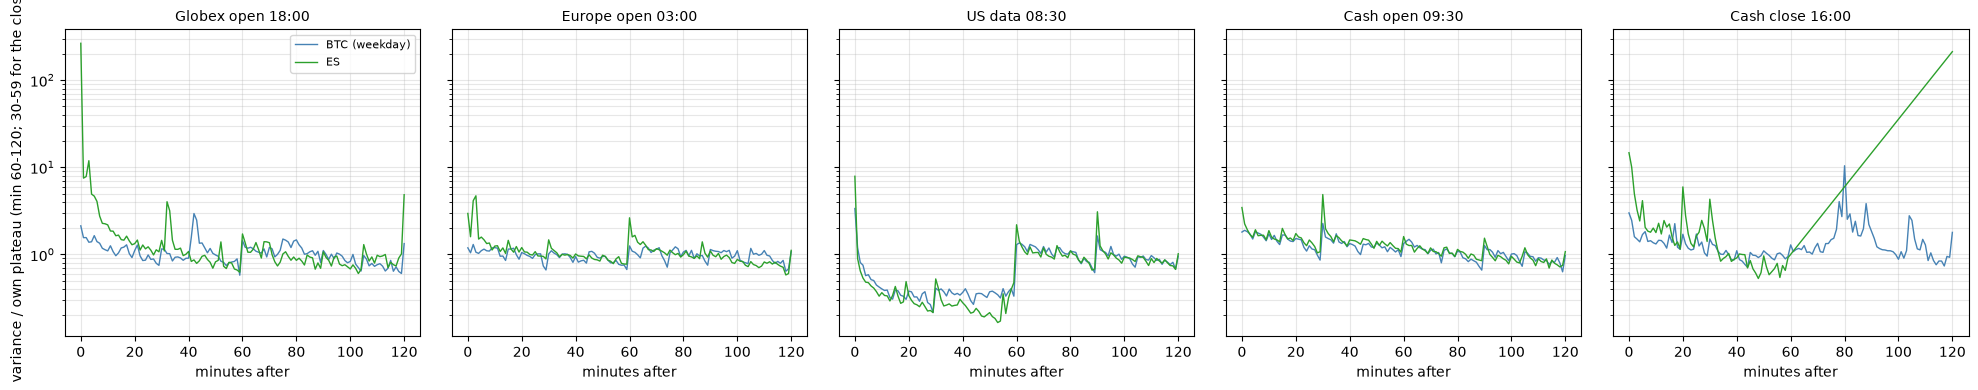

In [7]:
pb = btc_rv.groupby(["weekend", "tod"]).rv.mean().unstack("weekend")
pb.columns = ["weekday", "weekend"]; pb["ratio"] = pb.weekday / pb.weekend; pb["s"] = sess(pb.index); pb = pb.sort_values("s")
pe_ = es_rv.groupby("tod").rv.mean().rename("es").to_frame(); pe_["s"] = sess(pe_.index); pe_ = pe_.sort_values("s")

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(pb.s, ann(pb.weekday, MIN_PER_YR_24_7), lw=0.8, color="steelblue", label="BTC weekday")
axes[0].plot(pb.s, ann(pb.weekend, MIN_PER_YR_24_7), lw=0.8, color="tab:orange", label="BTC weekend")
axes[0].plot(pe_.s, ann(pe_.es), lw=0.8, color="tab:green", alpha=0.8, label="ES (trading-time annualisation)")
axes[0].set_yscale("log"); axes[0].set_ylabel("annualised vol"); axes[0].legend(fontsize=8, loc="upper left"); axes[0].grid(alpha=0.3, which="both")
axes[1].plot(pb.s, pb.ratio, lw=0.8, color="k"); axes[1].plot(pb.s, pb.ratio.rolling(15, center=True).median(), lw=1.8, color="crimson", label="15-min rolling median")
axes[1].axhline(1, color="grey", lw=0.6); axes[1].set_ylabel("BTC variance: weekday / weekend"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
for ax in axes:
    for m in EVENTS.values(): ax.axvline(sess(m), color="grey", lw=0.6, ls=":")
ticks = np.arange(0, 1441, 60); axes[1].set_xticks(ticks); axes[1].set_xticklabels([hhmm(18 * 60 + t) for t in ticks], rotation=90, fontsize=8)
fig.suptitle("BTC realised vol by minute of day (ET): weekday vs weekend, and their ratio — spikes at US times only on weekdays are US-market effects"); fig.tight_layout()

# Decay after opens: BTC (weekday) vs ES, minutes 0..120, as multiples of each series' own plateau (minutes 60..120)
OPENS = {"Globex open 18:00": 18 * 60, "Europe open 03:00": 3 * 60, "US data 08:30": 8 * 60 + 30, "Cash open 09:30": 9 * 60 + 30, "Cash close 16:00": 16 * 60}
PLATEAU = {"Cash close 16:00": (30, 59)}                                       # ES has no minutes 60-120 after the close (break)
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True); rows = []
bw = btc_rv[~btc_rv.weekend]
for ax, (name, t0) in zip(axes, OPENS.items()):
    for lab, d, colour in (("BTC (weekday)", bw, "steelblue"), ("ES", es_rv, "tab:green")):
        t = (d.tod - t0) % 1440; m = t <= 120
        curve = d[m].groupby(t[m]).rv.mean(); lo_, hi_ = PLATEAU.get(name, (60, 120)); plateau = curve.loc[lo_:hi_].mean()
        ax.plot(curve.index, curve / plateau, lw=1, color=colour, label=lab)
        rows.append({"event": name, "series": lab, "var at k=0 / plateau": curve.iloc[0] / plateau, "k=1": curve.iloc[1] / plateau, "k=5": curve.iloc[5] / plateau, "k=15": curve.iloc[15] / plateau, "k=30": curve.iloc[30] / plateau})
    ax.set_yscale("log"); ax.set_title(name, fontsize=10); ax.grid(alpha=0.3, which="both"); ax.set_xlabel("minutes after")
axes[0].set_ylabel("variance / own plateau (min 60-120; 30-59 for the close)"); axes[0].legend(fontsize=8); fig.tight_layout()
pd.DataFrame(rows).set_index(["event", "series"]).style.format("{:.2f}")

### How much each scheduled time raises vol — ES and BTC side by side

Empirical, no fitting: mean per-minute variance in short windows after each event as a **vol multiple** (`sqrt` of the
variance ratio) of (a) an average minute of the whole sample and (b) the pre-event level (minutes −45…−15 the same
day). BTC weekdays only. 14:00 is averaged over all days (FOMC days are ~1 in 8).

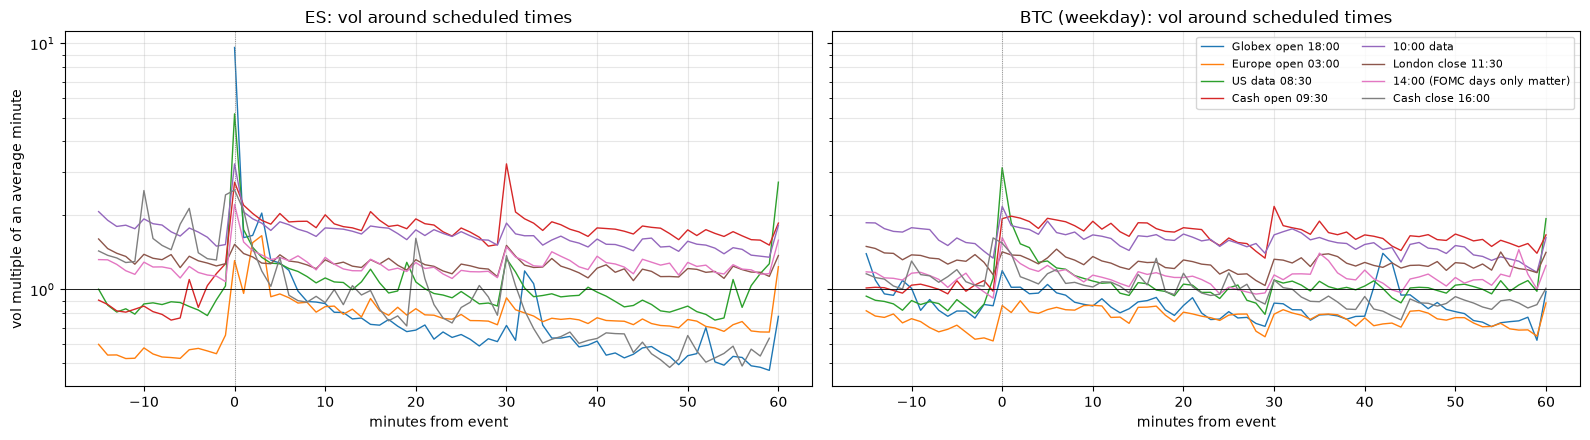

In [8]:
from volutils import event_lift, EVENT_TIMES

lift = pd.concat({"ES": event_lift(es_rv.rv, es_rv.tod), "BTC (weekday)": event_lift(btc_rv.rv[~btc_rv.weekend], btc_rv.tod[~btc_rv.weekend])}, names=["series", "event"]).swaplevel().sort_index(level=0, sort_remaining=False)
avg_cols = [c for c in lift.columns if "avg minute" in c]; pre_cols = [c for c in lift.columns if "x pre-event" in c]
display(lift[avg_cols].style.format("{:.2f}", na_rep="–").background_gradient(cmap="Reds", vmin=0.5, vmax=3, axis=None).set_caption("vol multiple of an AVERAGE minute"))
display(lift[pre_cols].style.format("{:.2f}", na_rep="–").background_gradient(cmap="Reds", vmin=0.5, vmax=3, axis=None).set_caption("vol multiple of the PRE-EVENT level (minutes -45..-15)"))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), sharey=True)
for ax, (lab, d) in zip(axes, (("ES", es_rv), ("BTC (weekday)", btc_rv[~btc_rv.weekend]))):
    for name, t0 in EVENT_TIMES.items():
        k = (d.tod - t0) % 1440; k = k.where(k <= 720, k - 1440); m = k.between(-15, 60)
        prof = d[m].groupby(k[m]).rv.mean(); ax.plot(prof.index, np.sqrt(prof / d.rv.mean()), lw=1, label=name)
    ax.axhline(1, color="k", lw=0.6); ax.axvline(0, color="grey", lw=0.6, ls=":"); ax.set_yscale("log"); ax.set_title(f"{lab}: vol around scheduled times"); ax.set_xlabel("minutes from event"); ax.grid(alpha=0.3, which="both")
axes[0].set_ylabel("vol multiple of an average minute"); axes[1].legend(fontsize=8, ncol=2); fig.tight_layout()

## 4. BTC vol response to ES moves

Minutes when ES is open, both series deseasonalised (`x_es`, `x_btc`). Two views:

- **Conditional table**: bucket ES's last-minute |return| (in units of that minute-of-day's typical ES vol) and
  ES's deseasonalised variance over the last 5 minutes; report BTC's variance ratio over the *next* 5 minutes.
- **Event study**: ES top-1% vol minutes → BTC's `x` from 30 min before to 120 min after, next to BTC's own
  shocks, and to ES's response to BTC shocks (the reverse direction).

In [9]:
es_x, _ = deseasonalise(es_rv.rv, es_rv.tod)
j = pd.DataFrame({"x_es": es_x[es_rv.n >= MIN_N], "x_btc": xb.x}).dropna()
j = j.join(btc_rv[["tod", "dow"]], how="left")
# ES 1-min return from the 10-s grid, scaled by that minute-of-day's typical ES vol
es_1m = grid.es[(grid.index.asi8 % (60 * 10**9)) == 0]; r_es = np.log(es_1m).diff()
r_es = r_es[grid.es_roll.reindex(r_es.index).fillna(False).to_numpy() == False]
z_es = (r_es / np.sqrt(es_rv.groupby("tod").rv.mean().reindex(tod_dow(r_es.index)[0]).to_numpy())).rename("z_es")
j = j.join(z_es, how="inner")
# forward 5-min BTC variance ratio: mean of x_btc over t+1..t+5 (clock minutes)
xb_full = xb.x.reindex(pd.date_range(xb.index[0], xb.index[-1], freq="1min", tz="UTC"))
fwd5 = xb_full[::-1].rolling(5, min_periods=3).mean()[::-1].shift(-1).rename("x_btc_next5")
back5_es = j.x_es.rolling(5, min_periods=3).mean().rename("x_es_last5")
j = j.join(fwd5, how="inner").join(back5_es, how="left").dropna()
print(f"{len(j):,} joint minutes")

j["|z_es| bucket"] = pd.cut(j.z_es.abs(), [0, 0.5, 1, 2, 3, 5, np.inf], right=False)
j["x_es last5 decile"] = pd.qcut(j.x_es_last5, 10, labels=[f"D{i}" for i in range(1, 11)])
t1 = j.groupby("|z_es| bucket", observed=True).agg(n=("x_btc_next5", "size"), btc_var_ratio_next5=("x_btc_next5", "mean"), btc_var_ratio_same_min=("x_btc", "mean"))
t2 = j.groupby("x_es last5 decile", observed=True).agg(n=("x_btc_next5", "size"), btc_var_ratio_next5=("x_btc_next5", "mean"), btc_var_ratio_same_min=("x_btc", "mean"))
for t in (t1, t2):
    t["btc_vol_ratio_next5"] = np.sqrt(t.btc_var_ratio_next5)
display(t1.style.format({"n": "{:,}", "btc_var_ratio_next5": "{:.2f}", "btc_var_ratio_same_min": "{:.2f}", "btc_vol_ratio_next5": "{:.2f}"}).set_caption("BTC vol over the next 5 min vs the size of ES's last 1-min move (in ES tod-sd units)"))
display(t2.style.format({"n": "{:,}", "btc_var_ratio_next5": "{:.2f}", "btc_var_ratio_same_min": "{:.2f}", "btc_vol_ratio_next5": "{:.2f}"}).set_caption("... vs decile of ES's deseasonalised variance over the last 5 min"))

# Does the ES move add anything once BTC's own recent vol is known?
j["x_btc_last5"] = j.x_btc.rolling(5, min_periods=3).mean()
jj = j.dropna(subset=["x_btc_last5"])
for cols in (["x_btc_last5"], ["x_es_last5"], ["x_btc_last5", "x_es_last5"], ["x_btc_last5", "x_es_last5", "abs_z_es"]):
    Xr = np.log(jj[[c for c in cols if c != "abs_z_es"]].clip(lower=1e-4)); 
    if "abs_z_es" in cols: Xr["abs_z_es"] = jj.z_es.abs()
    f = sm.OLS(np.log(jj.x_btc_next5.clip(lower=1e-4)), sm.add_constant(Xr)).fit()
    print(f"log BTC next-5min var on {cols}: R2 {f.rsquared:.3f}, betas {dict(f.params.round(3))}")

873,071 joint minutes


,n,btc_var_ratio_next5,btc_var_ratio_same_min,btc_vol_ratio_next5
|z_es| bucket,,,,
"[0.0, 0.5)","471,640",0.94,0.93,0.97
"[0.5, 1.0)","222,153",1.04,1.04,1.02
"[1.0, 2.0)","132,857",1.32,1.33,1.15
"[2.0, 3.0)","29,482",1.96,2.01,1.40
"[3.0, 5.0)","12,638",2.88,3.00,1.70
"[5.0, inf)","4,301",5.48,6.25,2.34


,n,btc_var_ratio_next5,btc_var_ratio_same_min,btc_vol_ratio_next5
x_es last5 decile,,,,
D1,"87,308",0.76,0.75,0.87
D2,"87,307",0.82,0.80,0.91
D3,"87,307",0.82,0.80,0.91
D4,"87,307",0.84,0.83,0.91
D5,"87,307",0.82,0.82,0.91
D6,"87,307",0.87,0.84,0.93
D7,"87,307",0.95,0.95,0.97
D8,"87,307",1.07,1.07,1.03
D9,"87,307",1.37,1.35,1.17


log BTC next-5min var on ['x_btc_last5']: R2 0.620, betas {'const': np.float64(-0.155), 'x_btc_last5': np.float64(0.793)}
log BTC next-5min var on ['x_es_last5']: R2 0.096, betas {'const': np.float64(-0.491), 'x_es_last5': np.float64(0.359)}


log BTC next-5min var on ['x_btc_last5', 'x_es_last5']: R2 0.623, betas {'const': np.float64(-0.129), 'x_btc_last5': np.float64(0.775), 'x_es_last5': np.float64(0.063)}
log BTC next-5min var on ['x_btc_last5', 'x_es_last5', 'abs_z_es']: R2 0.623, betas {'const': np.float64(-0.138), 'x_btc_last5': np.float64(0.775), 'x_es_last5': np.float64(0.059), 'abs_z_es': np.float64(0.009)}


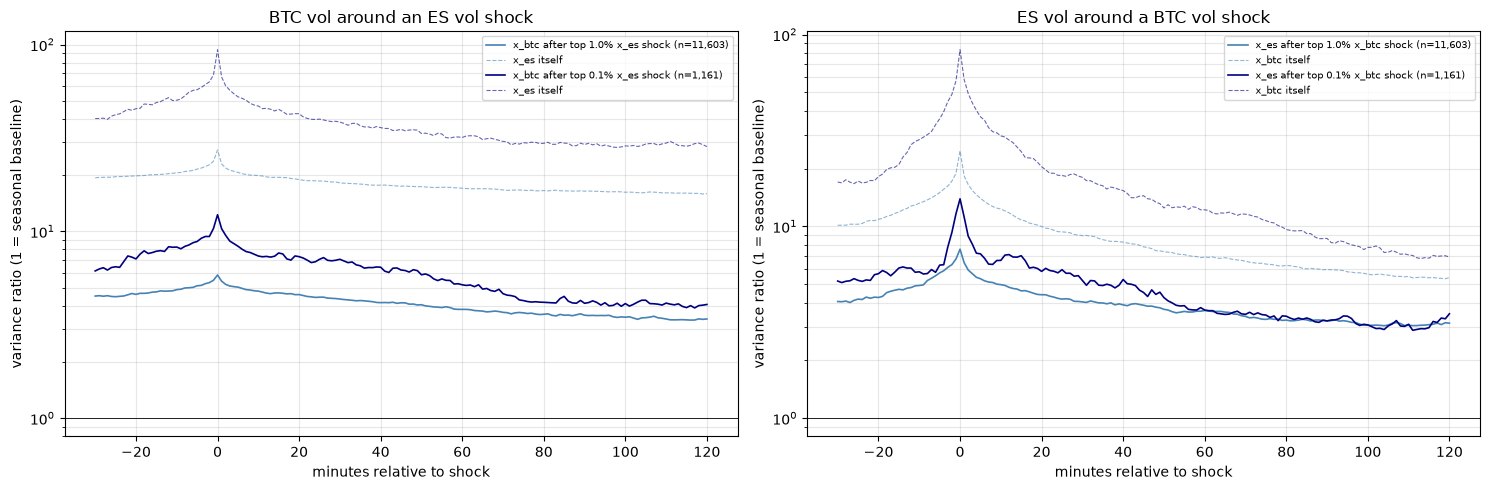

In [10]:
# Event study, both directions
K, PRE = 120, 30
jx = pd.DataFrame({"x_es": es_x, "x_btc": btc_rv.x}).dropna()
jx = jx[(es_rv.n.reindex(jx.index) >= MIN_N) & (btc_rv.n.reindex(jx.index) >= MIN_N)]
fig, axes = plt.subplots(1, 2, figsize=(15, 5)); rows = []
for ax, (src, tgt) in zip(axes, (("x_es", "x_btc"), ("x_btc", "x_es"))):
    for q, colour in ((0.99, "steelblue"), (0.999, "navy")):
        pos = np.flatnonzero(jx[src].to_numpy() > jx[src].quantile(q))
        ks, resp, nn = shock_response(jx[tgt].to_numpy(), pos, K, PRE)
        ks2, own, _ = shock_response(jx[src].to_numpy(), pos, K, PRE)
        ax.plot(ks, resp, lw=1.2, color=colour, label=f"{tgt} after top {1 - q:.1%} {src} shock (n={nn:,})")
        ax.plot(ks2, own, lw=0.8, color=colour, ls="--", alpha=0.6, label=f"{src} itself")
        rows.append({"shock in": src, "response of": tgt, "quantile": q, "n": nn, "at -1": resp[ks == -1][0], "at 0": resp[ks == 0][0], "at +1": resp[ks == 1][0],
                     "at +5": resp[ks == 5][0], "at +15": resp[ks == 15][0], "at +60": resp[ks == 60][0], "first k with excess < 25%": next((int(k) for k in range(1, K) if resp[ks == k][0] - 1 < 0.25), np.nan)})
    ax.axhline(1, color="k", lw=0.6); ax.set_yscale("log"); ax.set_xlabel("minutes relative to shock"); ax.set_ylabel("variance ratio (1 = seasonal baseline)"); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=7)
axes[0].set_title("BTC vol around an ES vol shock"); axes[1].set_title("ES vol around a BTC vol shock"); fig.tight_layout()
pd.DataFrame(rows).set_index(["shock in", "response of", "quantile"]).style.format("{:.3g}", na_rep="-")

## 5. Co-movement of ES and BTC vol, made stationary

On 5-min windows when ES is open. `lx_es`, `lx_btc` are deseasonalised log RV. Their **levels** are highly
persistent (long memory above) and share regimes, so a level correlation mostly says "high-vol weeks are high-vol
weeks". To get at *how BTC vol moves with an increase in ES vol*, the same statistics are computed on three
stationary transforms:

- `Δ lx` — first differences (window-to-window change in log vol);
- AR(12) residuals — the part of each series' vol that its own last hour did not predict (innovations);
- HAR residuals — same with 5-min / 30-min / 2-h / 24-h means as predictors.

For each: contemporaneous correlation, the cross-correlation function at leads/lags of ±12 windows (positive lag =
ES leads), a regression of the BTC innovation on the ES innovation split by **sign** of the ES change (rises vs
falls), and a rolling 30-day correlation of the innovations to see whether the coupling has changed over time.

219,145 joint 5-min windows


,corr (same window),beta BTC on ES,beta | ES up,beta | ES down,corr ES(t-1)->BTC(t),corr BTC(t-1)->ES(t),n
transform,,,,,,,
levels (log x),0.303,0.356,0.616,0.152,0.277,0.278,"219,145"
Δ log x,0.147,0.238,0.302,0.233,-0.041,-0.038,"219,144"
AR(12) residuals,0.170,0.267,0.361,0.214,0.034,0.023,"219,133"
HAR residuals,0.171,0.267,0.367,0.211,0.034,0.021,"218,857"


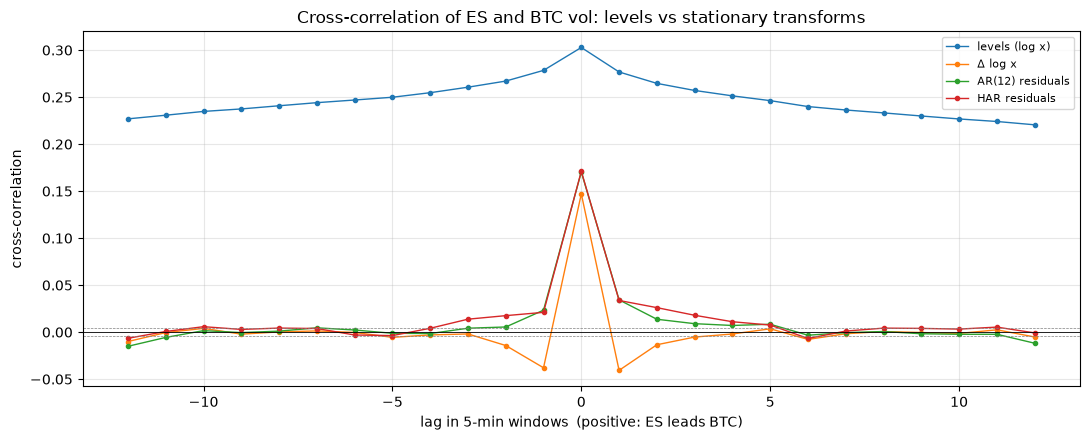

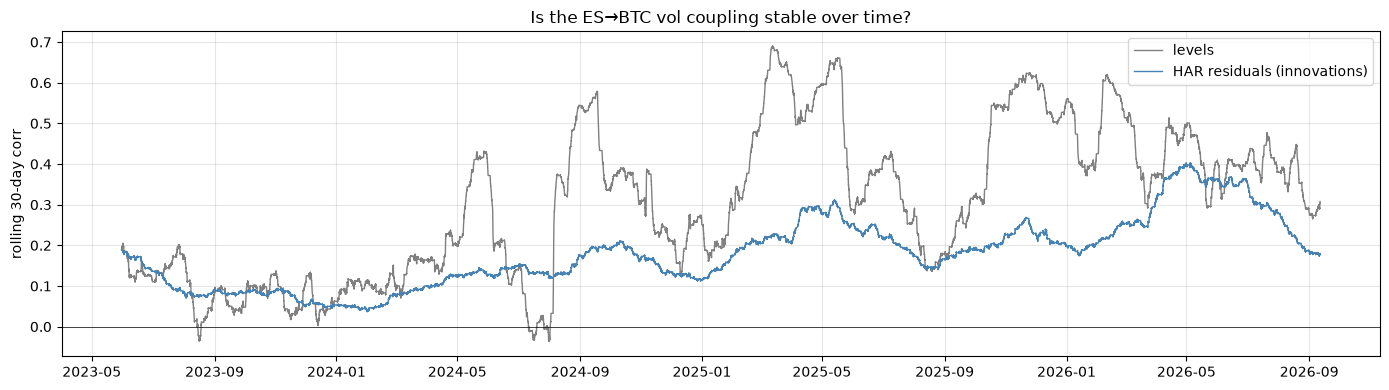

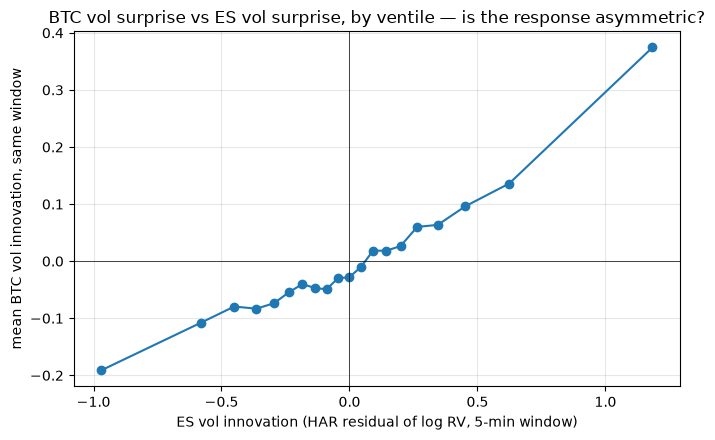

In [11]:
es5 = es_rv.groupby(es_rv.index.floor("5min")).agg(rv=("rv", "sum"), n=("n", "sum")); es5 = es5[es5.n >= 150]
es5["tod"], _ = tod_dow(es5.index); es5["x"], _ = deseasonalise(es5.rv, es5.tod); es5["lx"] = np.log(es5.x)
v = pd.DataFrame({"lx_es": es5.lx, "lx_btc": rv5.lx}).dropna()
v = v[v.index.to_series().diff() == pd.Timedelta("5min")]                    # consecutive windows only (ES open)
print(f"{len(v):,} joint 5-min windows")

def ar_resid(s, p):
    X = pd.concat([s.shift(k) for k in range(1, p + 1)], axis=1); X.columns = [f"l{k}" for k in range(1, p + 1)]
    return sm.OLS(s, sm.add_constant(X), missing="drop").fit().resid
def har_resid(s):
    X = pd.DataFrame({"l1": s.shift(1), "m6": s.shift(1).rolling(6).mean(), "m24": s.shift(1).rolling(24).mean(), "m288": s.shift(1).rolling(288).mean()})
    return sm.OLS(s, sm.add_constant(X), missing="drop").fit().resid

T = {"levels (log x)": v, "Δ log x": v.diff().dropna(),
     "AR(12) residuals": pd.DataFrame({"lx_es": ar_resid(v.lx_es, 12), "lx_btc": ar_resid(v.lx_btc, 12)}).dropna(),
     "HAR residuals": pd.DataFrame({"lx_es": har_resid(v.lx_es), "lx_btc": har_resid(v.lx_btc)}).dropna()}
L = 12; rows = []
fig, ax = plt.subplots(figsize=(11, 4.5))
for name, d in T.items():
    a, b = d.lx_es.to_numpy(), d.lx_btc.to_numpy(); a = (a - a.mean()) / a.std(); b = (b - b.mean()) / b.std(); n = len(a)
    ccf = np.array([(a[:n - k] * b[k:]).mean() if k >= 0 else (a[-k:] * b[:n + k]).mean() for k in range(-L, L + 1)])
    ax.plot(range(-L, L + 1), ccf, marker="o", ms=3, lw=1, label=name)
    up, dn = d.lx_es > 0, d.lx_es < 0                                        # for Δ / residuals: ES vol rose vs fell
    beta = np.polyfit(d.lx_es, d.lx_btc, 1)[0]
    rows.append({"transform": name, "corr (same window)": np.corrcoef(d.lx_es, d.lx_btc)[0, 1],
                 "beta BTC on ES": beta, "beta | ES up": np.polyfit(d.lx_es[up], d.lx_btc[up], 1)[0], "beta | ES down": np.polyfit(d.lx_es[dn], d.lx_btc[dn], 1)[0],
                 "corr ES(t-1)->BTC(t)": ccf[L + 1], "corr BTC(t-1)->ES(t)": ccf[L - 1], "n": n})
ax.axhline(0, color="k", lw=0.6); ax.axhline(2 / np.sqrt(len(v)), color="grey", lw=0.5, ls="--"); ax.axhline(-2 / np.sqrt(len(v)), color="grey", lw=0.5, ls="--")
ax.set_xlabel("lag in 5-min windows  (positive: ES leads BTC)"); ax.set_ylabel("cross-correlation"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title("Cross-correlation of ES and BTC vol: levels vs stationary transforms"); fig.tight_layout()
cc = pd.DataFrame(rows).set_index("transform")
display(cc.style.format("{:.3f}", subset=cc.columns[:-1]).format("{:,}", subset=["n"]))

# rolling 30-day correlation of innovations (HAR residuals), and of levels, over the sample
r = T["HAR residuals"]; lv = T["levels (log x)"]
fig, ax = plt.subplots(figsize=(14, 4))
for d, lab, colour in ((lv, "levels", "grey"), (r, "HAR residuals (innovations)", "steelblue")):
    rc = d.lx_es.rolling(30 * 276, min_periods=10 * 276).corr(d.lx_btc)          # ~276 ES windows per trading day
    ax.plot(rc.index, rc, lw=1, color=colour, label=lab)
ax.axhline(0, color="k", lw=0.5); ax.set_ylabel("rolling 30-day corr"); ax.legend(); ax.grid(alpha=0.3); ax.set_title("Is the ES→BTC vol coupling stable over time?"); fig.tight_layout()

# Asymmetry in detail: BTC vol innovation as a function of the ES vol innovation, binned
d = T["HAR residuals"]; bins = pd.qcut(d.lx_es, 20, labels=False)
bb = d.groupby(bins).agg(es_innov=("lx_es", "mean"), btc_innov=("lx_btc", "mean"), n=("lx_btc", "size"))
fig, ax = plt.subplots(figsize=(7, 4.5)); ax.plot(bb.es_innov, bb.btc_innov, marker="o"); ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("ES vol innovation (HAR residual of log RV, 5-min window)"); ax.set_ylabel("mean BTC vol innovation, same window"); ax.grid(alpha=0.3)
ax.set_title("BTC vol surprise vs ES vol surprise, by ventile — is the response asymmetric?"); fig.tight_layout()

## 6. Beta from ES to BTC across time frames

From the 10-s grid, ES-open periods only, consecutive grid points, no contract rolls. For each horizon `h`:
`β = cov(r_btc, r_es) / var(r_es)`, correlation, and R². Then:

- **lead–lag** at 10 s and 1 min: BTC(t) on ES(t−k) for k = −6…+6 — does ES lead BTC (k > 0) or the other way?
- **by session** and **rolling 30-day** at 5 min — is the coupling stable?
- **by ES move size** at 5 min — is beta larger when ES moves a lot (what you'd trade on)?
- **within a 5-min window**: given ES's and BTC's moves over the first `k` minutes, what does the regression say
  about BTC over the remaining `5−k`? This is the number that matters for an up/down market entered mid-window.

,n,beta (BTC on ES),corr,R2,sd BTC,sd ES,vol ratio BTC/ES,beta ES on BTC
horizon,,,,,,,,
10s,"5,281,026",0.802,0.309,0.096,0.00030,0.00011,2.59,0.119
30s,"1,485,493",0.904,0.348,0.121,0.00055,0.00021,2.60,0.134
1min,"636,010",0.946,0.371,0.138,0.00082,0.00032,2.55,0.145
5min,"125,601",1.019,0.404,0.163,0.00183,0.00073,2.52,0.160
15min,"39,893",1.062,0.430,0.185,0.00318,0.00129,2.47,0.174
1h,"9,606",1.156,0.462,0.214,0.00639,0.00255,2.50,0.185
4h,"2,198",1.163,0.466,0.217,0.01269,0.00508,2.50,0.186
1D,85,1.090,0.592,0.350,0.03202,0.01737,1.84,0.321


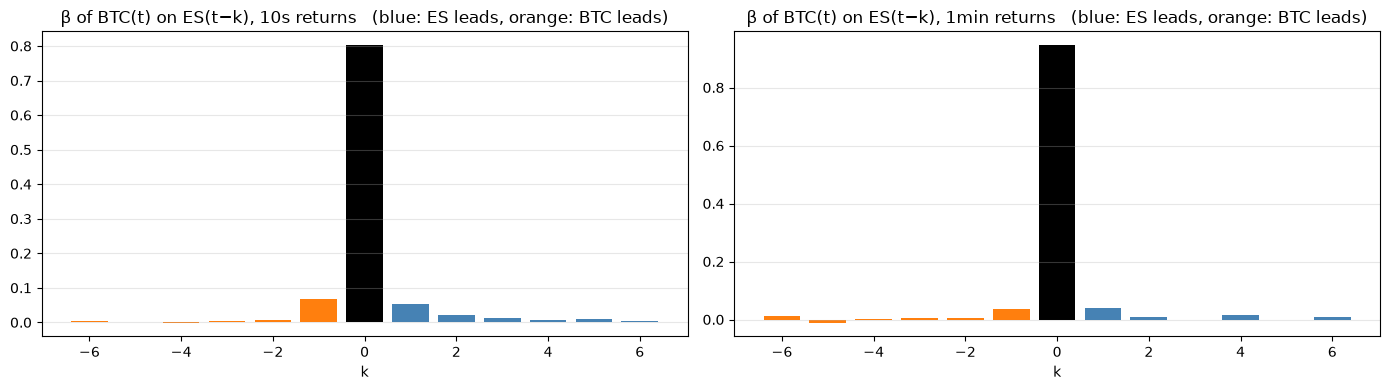

In [12]:
g = grid[grid.es.notna()].copy()
g["ok"] = (g.index.to_series().diff() == pd.Timedelta("10s")) & ~g.es_roll
lb, le = np.log(g.btc), np.log(g.es)

def rets_at(h):
    '''BTC and ES log returns over horizon h (a pandas offset) on the epoch-aligned grid, ES open and no roll inside the interval'''
    hn = int(pd.Timedelta(h).value); on = (g.index.asi8 % hn) == 0
    pb_, pe2 = lb[on], le[on]
    okh = (pb_.index.to_series().diff() == pd.Timedelta(h)) & (~g.es_roll.groupby(g.index.floor(h)).any().reindex(pb_.index).fillna(True))
    d = pd.DataFrame({"btc": pb_.diff(), "es": pe2.diff()})[okh].dropna()
    # inside the interval ES must have been quoted throughout: require the count of grid points to be complete
    cnt = g.es.groupby(g.index.floor(h)).size().reindex(pb_.index).shift(1); full = cnt >= hn // (10 * 10**9) * 0.9
    return d[full.reindex(d.index).fillna(False)]

HORIZONS = ["10s", "30s", "1min", "5min", "15min", "1h", "4h", "1D"]
rows, R = [], {}
for h in HORIZONS:
    d = rets_at(h); R[h] = d
    beta = np.cov(d.btc, d.es)[0, 1] / d.es.var(); corr = d.btc.corr(d.es)
    rows.append({"horizon": h, "n": len(d), "beta (BTC on ES)": beta, "corr": corr, "R2": corr ** 2,
                 "sd BTC": d.btc.std(), "sd ES": d.es.std(), "vol ratio BTC/ES": d.btc.std() / d.es.std(),
                 "beta ES on BTC": np.cov(d.btc, d.es)[0, 1] / d.btc.var()})
bt = pd.DataFrame(rows).set_index("horizon")
display(bt.style.format({"n": "{:,}", "beta (BTC on ES)": "{:.3f}", "corr": "{:.3f}", "R2": "{:.3f}", "sd BTC": "{:.5f}", "sd ES": "{:.5f}", "vol ratio BTC/ES": "{:.2f}", "beta ES on BTC": "{:.3f}"}))

# lead-lag at 10s and 1min
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, h in zip(axes, ("10s", "1min")):
    d = R[h]; ks = range(-6, 7)
    b = [np.cov(d.btc[max(k, 0):len(d) - max(-k, 0)].to_numpy(), d.es.shift(k).dropna().to_numpy()[:len(d) - abs(k)])[0, 1] / d.es.var() if k != 0 else np.cov(d.btc, d.es)[0, 1] / d.es.var() for k in ks]
    ax.bar(list(ks), b, color=["steelblue" if k > 0 else ("k" if k == 0 else "tab:orange") for k in ks])
    ax.set_title(f"β of BTC(t) on ES(t−k), {h} returns   (blue: ES leads, orange: BTC leads)"); ax.set_xlabel("k"); ax.grid(alpha=0.3, axis="y")
fig.tight_layout()

,n,beta,corr,sd BTC (ann.),sd ES (ann. 24/7 clock)
session,,,,,
Globex reopen 18-19,890,0.330,0.240,0.712,0.518
Asia 19-03,"17,433",1.217,0.357,0.564,0.166
Europe 03-08:30,"28,972",0.868,0.348,0.455,0.182
US pre 08:30-09:30,"8,868",1.100,0.430,0.569,0.223
Cash open 09:30-10:30,"10,014",1.118,0.460,0.864,0.355
US midday 10:30-14,"34,565",1.134,0.439,0.640,0.248
US pm 14-16,"19,485",0.954,0.414,0.552,0.239
Post-close 16-17,"5,174",0.661,0.286,0.581,0.252


,n,beta,corr,P(same sign),mean BTC | ES up,mean BTC | ES down
|ES move| bucket (sd),,,,,,
"[0.0, 0.5)","74,479",1.131,0.142,0.566,+0.00019,-0.00018
"[0.5, 1.0)","30,236",1.097,0.325,0.670,+0.00056,-0.00057
"[1.0, 2.0)","15,698",1.128,0.503,0.770,+0.00106,-0.00115
"[2.0, 3.0)","3,328",1.116,0.643,0.854,+0.00191,-0.00197
"[3.0, inf)","1,860",0.892,0.749,0.920,+0.00349,-0.00320


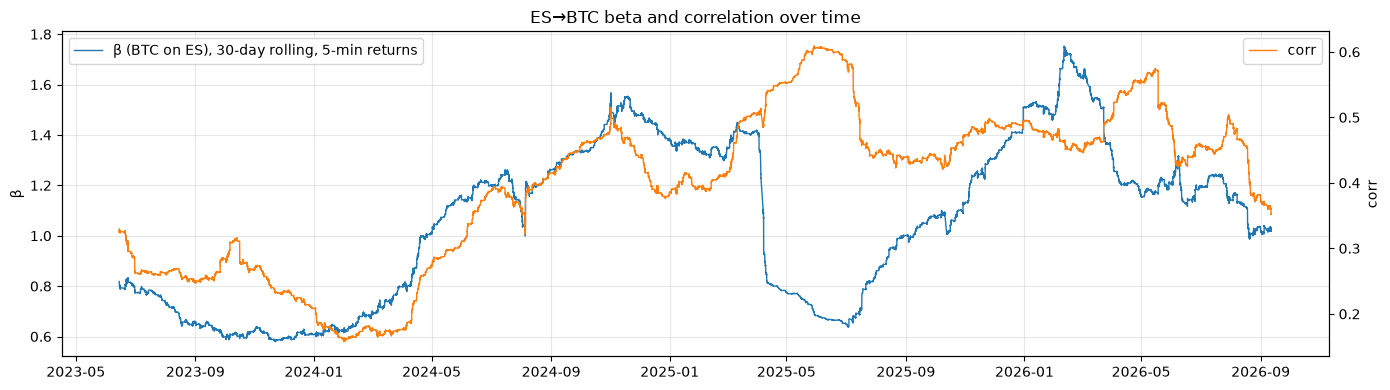

In [13]:
# 5-min beta by session, by ES move size, and rolling 30 days
d5 = R["5min"].copy(); d5["tod"], d5["dow"] = tod_dow(d5.index)
SESS = [("Globex reopen 18-19", 18 * 60, 19 * 60), ("Asia 19-03", 19 * 60, 27 * 60), ("Europe 03-08:30", 3 * 60, 8 * 60 + 30), ("US pre 08:30-09:30", 8 * 60 + 30, 9 * 60 + 30),
        ("Cash open 09:30-10:30", 9 * 60 + 30, 10 * 60 + 30), ("US midday 10:30-14", 10 * 60 + 30, 14 * 60), ("US pm 14-16", 14 * 60, 16 * 60), ("Post-close 16-17", 16 * 60, 17 * 60)]
rows = []
for name, a, b in SESS:
    t = d5.tod.where(d5.tod >= a, d5.tod + 1440) if b > 1440 else d5.tod
    s = d5[(t >= a) & (t < b)]
    rows.append({"session": name, "n": len(s), "beta": np.cov(s.btc, s.es)[0, 1] / s.es.var(), "corr": s.btc.corr(s.es), "sd BTC (ann.)": s.btc.std() * np.sqrt(ANN5), "sd ES (ann. 24/7 clock)": s.es.std() * np.sqrt(ANN5)})
display(pd.DataFrame(rows).set_index("session").style.format({"n": "{:,}", "beta": "{:.3f}", "corr": "{:.3f}", "sd BTC (ann.)": "{:.3f}", "sd ES (ann. 24/7 clock)": "{:.3f}"}).background_gradient(subset=["beta"], cmap="Blues"))

# by size of the ES move (absolute, in sd units) and by sign
d5["z"] = d5.es / d5.es.std(); d5["|z| bucket"] = pd.cut(d5.z.abs(), [0, 0.5, 1, 2, 3, np.inf], right=False)
rows = []
for (buck), s in d5.groupby("|z| bucket", observed=True):
    rows.append({"|ES move| bucket (sd)": str(buck), "n": len(s), "beta": np.cov(s.btc, s.es)[0, 1] / s.es.var(), "corr": s.btc.corr(s.es),
                 "P(same sign)": (np.sign(s.btc) == np.sign(s.es)).mean(), "mean BTC | ES up": s.btc[s.es > 0].mean(), "mean BTC | ES down": s.btc[s.es < 0].mean()})
display(pd.DataFrame(rows).set_index("|ES move| bucket (sd)").style.format({"n": "{:,}", "beta": "{:.3f}", "corr": "{:.3f}", "P(same sign)": "{:.3f}", "mean BTC | ES up": "{:+.5f}", "mean BTC | ES down": "{:+.5f}"}))

# rolling beta and correlation
W = 30 * 276
rb = d5.btc.rolling(W, min_periods=W // 3).cov(d5.es) / d5.es.rolling(W, min_periods=W // 3).var()
rc = d5.btc.rolling(W, min_periods=W // 3).corr(d5.es)
fig, ax = plt.subplots(figsize=(14, 4)); ax.plot(rb.index, rb, lw=1, label="β (BTC on ES), 30-day rolling, 5-min returns"); ax2 = ax.twinx(); ax2.plot(rc.index, rc, lw=1, color="tab:orange", label="corr")
ax.set_ylabel("β"); ax2.set_ylabel("corr"); ax.grid(alpha=0.3); ax.legend(loc="upper left"); ax2.legend(loc="upper right"); ax.set_title("ES→BTC beta and correlation over time"); fig.tight_layout()

In [14]:
# Within a 5-min window: what do ES's and BTC's moves over the first k minutes say about BTC over the remaining 5-k?
one = grid[(grid.index.asi8 % (60 * 10**9)) == 0][["btc", "es", "es_roll"]]
one["w"] = one.index.floor("5min"); one["k"] = one.index.minute % 5
piv_b = np.log(one.pivot(index="w", columns="k", values="btc")); piv_e = np.log(one.pivot(index="w", columns="k", values="es"))
nxt_b = piv_b[0].shift(-1)                                                    # BTC at the end of the window = start of the next
complete = piv_b.notna().all(axis=1) & piv_e.notna().all(axis=1) & nxt_b.notna() & (~one.groupby("w").es_roll.any().reindex(piv_b.index).fillna(True))
complete &= (pd.Series(piv_b.index, index=piv_b.index).diff() == pd.Timedelta("5min"))
piv_b, piv_e, nxt_b = piv_b[complete], piv_e[complete], nxt_b[complete]
print(f"{complete.sum():,} complete windows with ES open")
rows = []
for k in (1, 2, 3, 4):
    es_so_far, btc_so_far, btc_rest = piv_e[k] - piv_e[0], piv_b[k] - piv_b[0], nxt_b - piv_b[k]
    Xw = sm.add_constant(pd.DataFrame({"es first k": es_so_far, "btc first k": btc_so_far}))
    f_both = sm.OLS(btc_rest, Xw).fit(); f_es = sm.OLS(btc_rest, Xw[["const", "es first k"]]).fit(); f_btc = sm.OLS(btc_rest, Xw[["const", "btc first k"]]).fit()
    same = (np.sign(btc_rest) == np.sign(es_so_far))
    big = es_so_far.abs() > 2 * es_so_far.std()
    rows.append({"k (min elapsed)": k, "beta rest on ES so far": f_es.params["es first k"], "t": f_es.tvalues["es first k"], "R2 ES only": f_es.rsquared,
                 "beta rest on BTC so far": f_btc.params["btc first k"], "R2 BTC only": f_btc.rsquared, "R2 both": f_both.rsquared,
                 "P(rest of BTC same sign as ES so far)": same.mean(), "... when |ES so far| > 2sd": same[big].mean(), "n big": int(big.sum()),
                 "sd of BTC rest": btc_rest.std(), "sd BTC so far": btc_so_far.std()})
ww = pd.DataFrame(rows).set_index("k (min elapsed)")
ww.style.format("{:.4f}").format("{:,.0f}", subset=["n big"]).format("{:.2f}", subset=["t"])

137,493 complete windows with ES open


,beta rest on ES so far,t,R2 ES only,beta rest on BTC so far,R2 BTC only,R2 both,P(rest of BTC same sign as ES so far),... when |ES so far| > 2sd,n big,sd of BTC rest,sd BTC so far
k (min elapsed),,,,,,,,,,,
1,0.0585,5.02,0.0002,-0.0235,0.0002,0.0006,0.5012,0.4946,"5,000",0.0016,0.0009
2,0.0381,5.02,0.0002,-0.0055,0.0000,0.0003,0.5005,0.5017,"5,529",0.0013,0.0012
3,0.0148,2.91,0.0001,-0.0063,0.0001,0.0002,0.4984,0.5018,"5,518",0.0011,0.0014
4,0.0087,2.77,0.0001,-0.0017,0.0000,0.0001,0.4947,0.5036,"5,699",0.0007,0.0016


### Reading the results

- **§1** gives the base rates for the market: the typical 5-min vol by time of day, how often a window is a
  near coin-flip on a flat price, and whether the sign of the last window carries any information.
- **§2** says how far ahead BTC vol is knowable from BTC vol alone (`R2 out` at "next 5min"), and the decile table
  gives the practical multiplier: after a top-decile window, the next window's vol is `x` the seasonal normal.
- **§3** the weekday/weekend ratio isolates the US-market effect on BTC from the clock effect.
- **§4–5** the conditional tables and the innovation regressions answer "does an ES vol rise pass through to BTC
  vol, how fast, and asymmetrically?"; the CCF tells you which one leads. If the level correlation is high but the
  innovation correlation is small, the co-movement is regime, not transmission.
- **§6** the beta table by horizon shows where the coupling forms (a beta that grows from 10 s to 5 min with the
  lead–lag bars positive at k>0 means ES leads and BTC catches up within the window); the within-window table is the
  direct input for a mid-window entry rule.